In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
szabadeses_idok = np.array([
[155, 153, 147],
[181, 180, 181],
[203, 210, 207],
[230, 225, 229],
[248, 263, 257],
[272, 270, 272],
[286, 286, 296],
[306, 303, 304],
[321, 320, 319],
[335, 337, 342],
[350, 353, 353],
[369, 367, 370],
[382, 382, 381],
[396, 398, 403],
[407, 412, 408],
[417, 420, 426],
[435, 436, 432],
[443, 445, 445]
]) / 1000

magassagok = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]) / 100

szogek = np.array([0, 10, 20, 40, 45, 50, 70, 90])

tavolsagok = np.array([0, 15, 30, 45, 60, 75, 90]) / 100


mikola_idok = np.array([
[0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000],
[5.09300, 3.75200, 3.13800, 3.06500, 3.09600, 4.34900, 5.47500],
[10.62800, 8.02200, 6.34400, 6.37600, 6.50400, 8.69100, 11.42800],
[15.68200, 12.03600, 9.61000, 9.57700, 9.63200, 12.99200, 17.10200],
[20.97400, 16.16900, 12.85600, 12.92800, 12.94400, 17.54900, 23.03900],
[26.38500, 20.27800, 16.11400, 16.17600, 16.27200, 21.97000, 28.92100],
[31.74800, 24.36500, 19.40200, 19.40000, 19.66200, 26.51800, 34.97600],
]).transpose()

sebessegek = np.array([0, 2.83400, 3.67400, 4.63200, 4.61600, 4.57600, 3.39600, 2.57000]) / 100

illesztes_pontossagok = np.array([1.000000, 0.999900, 1.000000, 1.000000, 0.999900, 1.000000, 0.999900])

In [3]:
def linearis(x, m, b):
    return x * m + b

In [4]:
illesztesek = [None for i in range(len(mikola_idok))]
s = []
for i in range(len(illesztesek)):
    illesztesek[i] = curve_fit(linearis, mikola_idok[i], tavolsagok)
    s.append(illesztesek[i][0][0])
print(sebessegek)
print(s)

[0.      0.02834 0.03674 0.04632 0.04616 0.04576 0.03396 0.0257 ]
[np.float64(0.028342625474206965), np.float64(0.03674267814423578), np.float64(0.046319748703048835), np.float64(0.04616321767287138), np.float64(0.04575604512075693), np.float64(0.033962499382989564), np.float64(0.02569504596246126)]


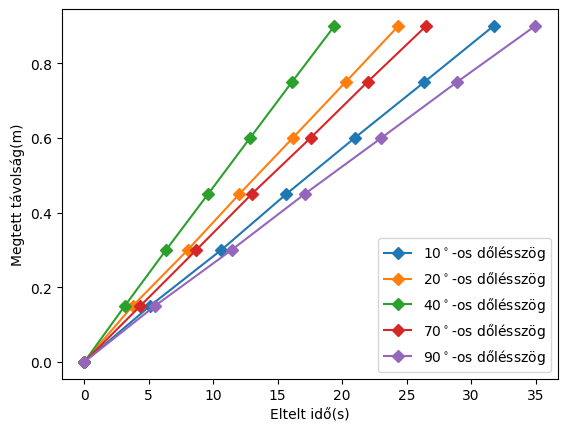

In [5]:
for i in range(len(mikola_idok)):
    if i == 3 or i == 4:
        continue
    plt.plot(mikola_idok[i], tavolsagok, "D-", label=str(szogek[i + 1])+"$^\\circ$-os dőlésszög")
plt.legend()
plt.xlabel("Eltelt idő(s)")
plt.ylabel("Megtett távolság(m)")
plt.show()

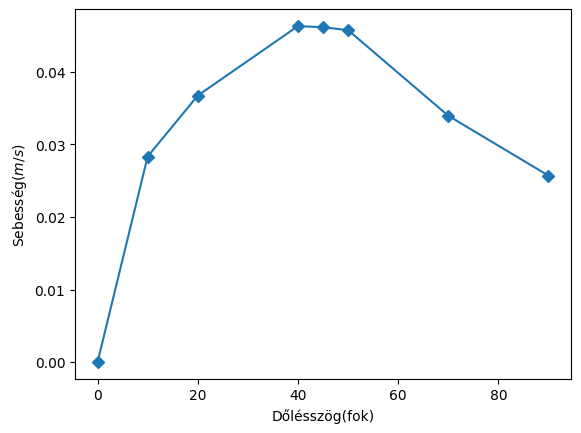

In [6]:
plt.plot(szogek, sebessegek, "D-")
plt.xlabel("Dőlésszög(fok)")
plt.ylabel("Sebesség$\\left(m/s\\right)$")
plt.show()

In [7]:
szabadeses_ido_atlagok = np.array([np.average(i) for i in szabadeses_idok])

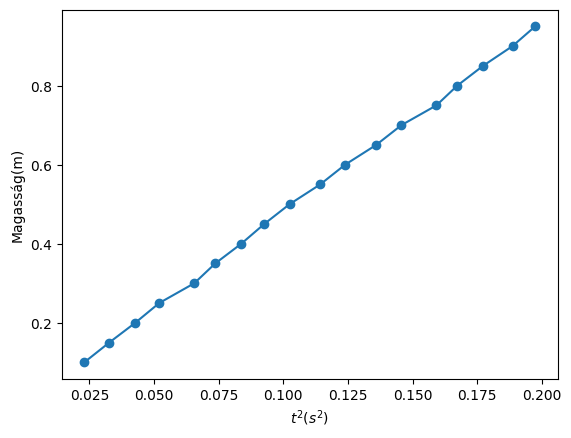

In [8]:
plt.plot(szabadeses_ido_atlagok ** 2, magassagok, "o-")
plt.xlabel("$t^2(s^2)$")
plt.ylabel("Magasság(m)")
plt.show()

In [9]:
szabadeses_illesztes = curve_fit(linearis, szabadeses_ido_atlagok ** 2, magassagok)

In [10]:
print(szabadeses_illesztes[0])
print(szabadeses_illesztes[0][0] * 2)

[ 4.82475029 -0.0051226 ]
9.6495005813306


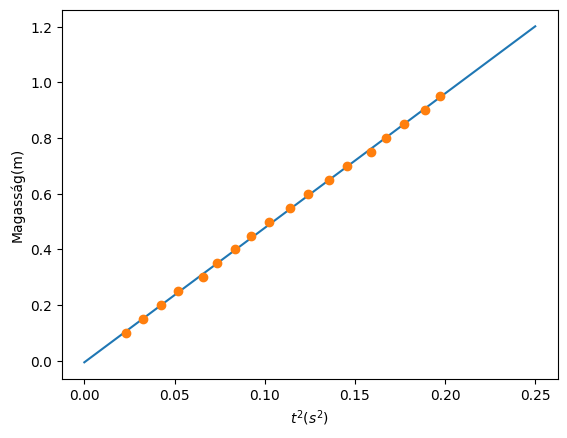

In [11]:
idok_linspace = np.linspace(0, 0.25, 100)
plt.plot(idok_linspace, linearis(idok_linspace, szabadeses_illesztes[0][0], szabadeses_illesztes[0][1]), label="Illesztett egyenes")
plt.plot(szabadeses_ido_atlagok ** 2, magassagok, "o", label="Mérésből származó pontok")
plt.xlabel("$t^2(s^2)$")
plt.ylabel("Magasság(m)")
plt.show()

In [12]:
for i in range(7):
    print(tavolsagok[i], end=" & ")
    print(mikola_idok[0][i], end=" & ")
    print(mikola_idok[1][i], end=" & ")
    print(mikola_idok[2][i], end=" & ")
    print(mikola_idok[3][i], end=" & ")
    print(mikola_idok[4][i], end=" & ")
    print(mikola_idok[5][i], end=" & ")
    print(mikola_idok[6][i], end=" ")
    print("\\\\")

0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
0.15 & 5.093 & 3.752 & 3.138 & 3.065 & 3.096 & 4.349 & 5.475 \\
0.3 & 10.628 & 8.022 & 6.344 & 6.376 & 6.504 & 8.691 & 11.428 \\
0.45 & 15.682 & 12.036 & 9.61 & 9.577 & 9.632 & 12.992 & 17.102 \\
0.6 & 20.974 & 16.169 & 12.856 & 12.928 & 12.944 & 17.549 & 23.039 \\
0.75 & 26.385 & 20.278 & 16.114 & 16.176 & 16.272 & 21.97 & 28.921 \\
0.9 & 31.748 & 24.365 & 19.402 & 19.4 & 19.662 & 26.518 & 34.976 \\


In [13]:
for i in range(7):
    print(illesztes_pontossagok[i], end=" & ")

1.0 & 0.9999 & 1.0 & 1.0 & 0.9999 & 1.0 & 0.9999 & 

In [14]:
for i in range(len(magassagok)):
    print(magassagok[i], end=" & ")
    print(szabadeses_idok[i][0], end=" & ")
    print(szabadeses_idok[i][1], end=" & ")
    print(szabadeses_idok[i][2], end=" & ")
    print(szabadeses_ido_atlagok[i], end=" ")
    print("\\\\")

0.1 & 0.155 & 0.153 & 0.147 & 0.15166666666666664 \\
0.15 & 0.181 & 0.18 & 0.181 & 0.18066666666666667 \\
0.2 & 0.203 & 0.21 & 0.207 & 0.20666666666666667 \\
0.25 & 0.23 & 0.225 & 0.229 & 0.228 \\
0.3 & 0.248 & 0.263 & 0.257 & 0.256 \\
0.35 & 0.272 & 0.27 & 0.272 & 0.27133333333333337 \\
0.4 & 0.286 & 0.286 & 0.296 & 0.2893333333333333 \\
0.45 & 0.306 & 0.303 & 0.304 & 0.30433333333333334 \\
0.5 & 0.321 & 0.32 & 0.319 & 0.32 \\
0.55 & 0.335 & 0.337 & 0.342 & 0.338 \\
0.6 & 0.35 & 0.353 & 0.353 & 0.35200000000000004 \\
0.65 & 0.369 & 0.367 & 0.37 & 0.36866666666666664 \\
0.7 & 0.382 & 0.382 & 0.381 & 0.38166666666666665 \\
0.75 & 0.396 & 0.398 & 0.403 & 0.399 \\
0.8 & 0.407 & 0.412 & 0.408 & 0.409 \\
0.85 & 0.417 & 0.42 & 0.426 & 0.421 \\
0.9 & 0.435 & 0.436 & 0.432 & 0.4343333333333333 \\
0.95 & 0.443 & 0.445 & 0.445 & 0.4443333333333333 \\


In [15]:
for i in range(len(szabadeses_ido_atlagok)):
    print(szabadeses_ido_atlagok[i]**2, end=" & ")
    print(magassagok[i], end=" & ")
    print(linearis(szabadeses_ido_atlagok[i]**2, szabadeses_illesztes[0][0], szabadeses_illesztes[0][1]), end=" & ")
    print(magassagok[i] - linearis(szabadeses_ido_atlagok[i]**2, szabadeses_illesztes[0][0], szabadeses_illesztes[0][1]), end=" ")
    print("\\\\")

0.02300277777777777 & 0.1 & 0.10586006342483956 & -0.005860063424839551 \\
0.032640444444444444 & 0.15 & 0.15235939847617486 & -0.002359398476174862 \\
0.04271111111111111 & 0.2 & 0.20094785040336818 & -0.0009478504033681723 \\
0.051984 & 0.25 & 0.24568722376534188 & 0.004312776234658117 \\
0.065536 & 0.3 & 0.311072239704438 & -0.011072239704437992 \\
0.0736217777777778 & 0.35 & 0.35008409838802645 & -8.409838802647673e-05 \\
0.08371377777777775 & 0.4 & 0.39877547832142046 & 0.0012245216785795598 \\
0.09261877777777779 & 0.45 & 0.4417398796597951 & 0.008260120340204902 \\
0.1024 & 0.5 & 0.4889318344195237 & 0.011068165580476297 \\
0.11424400000000001 & 0.55 & 0.5460761768621636 & 0.003923823137836457 \\
0.12390400000000003 & 0.6 & 0.5926832646699904 & 0.007316735330009538 \\
0.1359151111111111 & 0.65 & 0.6506338764945367 & -0.0006338764945367226 \\
0.14566944444444443 & 0.7 & 0.697696099079783 & 0.002303900920216928 \\
0.159201 & 0.75 & 0.7629824756796034 & -0.012982475679603422 \\
0.1

In [17]:
print(max(np.abs(magassagok - linearis(szabadeses_ido_atlagok**2, szabadeses_illesztes[0][0], szabadeses_illesztes[0][1]))))

0.012982475679603422


In [19]:
print(max(np.abs(magassagok - linearis(szabadeses_ido_atlagok**2, szabadeses_illesztes[0][0], szabadeses_illesztes[0][1])))/(0.1974-0.0230)*2)

0.1488816018303145
